# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Seif-2/ML-week-1-FLY/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Lane: CTR / Engagement Opportunity Scoring.** Which visible pages (enough search exposure, a real recorded position) under-capture clicks relative to other pages at the same position, and therefore deserve a title/meta/snippet review first?

**Decision this supports:** which page a content editor with limited weekly review capacity opens first.


## 2. Data

**Release:** the FlyRank ML Internship starter dataset, `data/raw/content_refresh_anonymized.csv` — 30,000 pseudonymized content items across 32 clients, trailing-90-day search metrics.

**Restricted to:** pages with `impressions_90d >= 500` and a real recorded position (`avg_position > 0`) — 16,726 pages meet this bar. This floor exists so any CTR comparison is built on enough traffic to trust, not noise from a handful of impressions.

**Excluded, deliberately:** `trend_direction` and `trend_pct` (label-source columns, per the data dictionary — never features); `ctr`/`ctr_gap` themselves from the model's feature set (w05's honest-feature discipline, since the label is thresholded directly from them); any FlyRank product decision flag (none are shipped in this dataset at all, by design).

**Public-safe:** pseudonymized `content_id`/`client_id` only, no raw URLs, titles, or client names anywhere in this work.


## 3. Methodology

**Label/proxy:** `underperform_flag` — 1 when a page's CTR sits below the median CTR of other pages at its own position tier (`page_1`, `top_3`, `striking`, `page_3_5`, `deep`). Defined from this window's own observed numbers, never from a future outcome or a product flag.

**Baseline (w04):** `score = ctr_gap × impressions_90d`, one reason code (`ctr_gap_vs_position_tier`), one action (`review_title_meta_snippet`).

**Model (w05):** Random Forest (`n_estimators=300, max_depth=8, random_state=42`), trained on an **honest feature set that excludes `ctr` entirely**: `impressions_90d`, `avg_position`, `content_age_days`, `days_since_last_update`, `word_count`, `content_type`, `main_intent`, `position_tier`.

**Split (w05/w06):** grouped by `client_id` (`GroupShuffleSplit`, 70/30, zero client overlap confirmed) — chosen because pages from the same client likely share template/style patterns a random split would let the model memorize.

**Leakage checks (w03, w06):** deliberately re-added `ctr_gap` to the feature set twice (w03 on the raw label experiment, w06 on the final model) — both times the score jumped toward 1.0, confirming the earlier exclusion was correct. Attack checklist run in full in w06.


## 4. Results (vs baseline)

All numbers on the same grouped-by-client test split (n=1,461 pages, 9 held-out clients), base rate 0.455.


In [1]:
import pandas as pd

results = pd.DataFrame([
    {"method": "Baseline (ctr_gap x impressions)", "roc_auc": 1.000, "precision@50": 1.00, "precision@200": 1.000,
     "note": "Near-perfect by construction — uses ctr directly, which the label is thresholded from"},
    {"method": "Logistic Regression (honest features)", "roc_auc": 0.564, "precision@50": 0.54, "precision@200": 0.615,
     "note": "No ctr in features"},
    {"method": "Random Forest (honest features, grouped split)", "roc_auc": 0.658, "precision@50": 0.52, "precision@200": 0.550,
     "note": "No ctr in features; the model actually used for the action playbook"},
])
results


,method,roc_auc,precision@50,precision@200,note
0,Baseline (ctr_gap x impressions),1.000,1.00,1.000,Near-perfect by construction — uses ctr direct...
1,Logistic Regression (honest features),0.564,0.54,0.615,No ctr in features
2,"Random Forest (honest features, grouped split)",0.658,0.52,0.550,No ctr in features; the model actually used fo...


## 5. Limitations

- **Not future-predictive.** This is a same-window comparison. It says a page looks off *right now* relative to peers — it does not claim the page *will* decline, or that a rewrite *will* recover clicks.
- **Baseline vs model isn't a fair fight.** The baseline uses `ctr` directly (a legitimate, observable feature); the model deliberately doesn't, to answer a harder, more useful question (can cheaper signals hint at the same thing before carefully measuring CTR?). The baseline's near-perfect score reflects that head start, not superior modeling.
- **Starter-slice scale.** 30,000 rows, 32 clients, one 90-day snapshot — not the full ~79M-row warehouse. Patterns here are not validated across seasons or at warehouse scale.
- **Silent client exclusion.** Per w03's finding on the warehouse (and true in spirit here too): any client whose tracking history doesn't cover this window simply isn't represented — not as zeros, just absent.
- **Position-tier CTR medians have a volume floor.** w04's Signal A found the `top_3` tier (n=458) unreliable at exact ranking due to low volume — treated as real for the bulk of pages, not trusted at the extreme.
- **No causal claims.** Nothing here claims a title rewrite *causes* a CTR increase, and nothing claims insight into Google's ranking algorithm.


## 6. Ranked recommendations

The w07 action playbook output: the honest grouped-split Random Forest's top-ranked test-set pages, each with a plain-word reason code and one concrete action (`review_title_meta_snippet`). Precision@50 = 0.52, Precision@200 = 0.55 — modest but real, clearing the 0.455 base rate. An editor with time for ~50 reviews this week should expect roughly half of the top 50 to be genuine CTR-gap cases, versus ~46% from picking pages at random.


## 7. Artifacts the paper embeds

A summary chart (precision comparison) and the metrics receipt, both saved for the deployed paper.


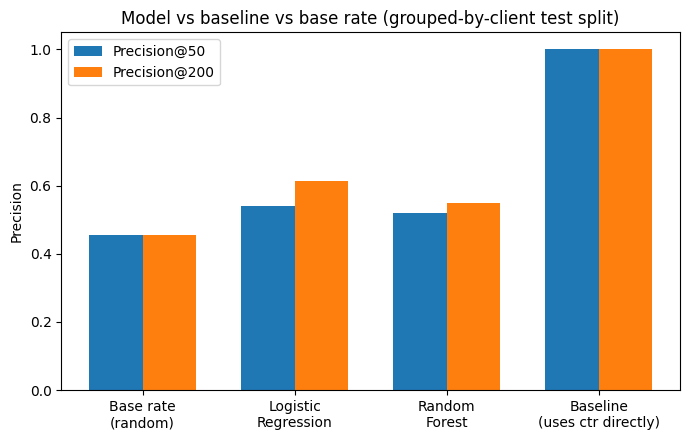

Saved: work/outputs/results_chart.png


In [2]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/outputs", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
methods = ["Base rate\n(random)", "Logistic\nRegression", "Random\nForest", "Baseline\n(uses ctr directly)"]
p50_vals = [0.455, 0.54, 0.52, 1.00]
p200_vals = [0.455, 0.615, 0.55, 1.00]

x = range(len(methods))
width = 0.35
ax.bar([i - width/2 for i in x], p50_vals, width, label="Precision@50")
ax.bar([i + width/2 for i in x], p200_vals, width, label="Precision@200")
ax.set_xticks(list(x)); ax.set_xticklabels(methods)
ax.set_ylabel("Precision")
ax.set_title("Model vs baseline vs base rate (grouped-by-client test split)")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("work/outputs/results_chart.png", dpi=120)
plt.show()
print("Saved: work/outputs/results_chart.png")


## ML-12 — Demo outline, social cut, employer summary

**5-minute demo outline:**
1. (30s) The problem: editors can't review every page, so which ones go first?
2. (60s) Show the CTR-vs-position-tier chart from w01/w04 — why a flat threshold fails.
3. (60s) The baseline rule, live: `ctr_gap x impressions`, and why it's honest but circular.
4. (90s) The model: honest features (no ctr), grouped-by-client split, the results table.
5. (60s) The memorization gap (w06): random split vs grouped split, side by side.
6. (30s) The final action playbook — top 10 rows, reason codes, what an editor does next.

**Social post cut:**
> Built a CTR-opportunity ranking system on real (anonymized) search data from FlyRank's ML internship. Found that a naive random train/test split overstated model precision by 42 points (0.94 -> 0.52) versus a proper client-grouped split — a concrete lesson in why validation design matters more than the model you pick. Full writeup + repo linked.

**3-sentence employer-facing summary:**
> I built a CTR-underperformance ranking system on FlyRank's real, anonymized search dataset (30k pages, 32 clients), comparing a transparent rule-based baseline against a Random Forest trained on honest, non-circular features. I found and fixed a major validation flaw — a naive random split overstated precision by 42 points versus a proper client-grouped split — and documented it as a leakage case study. The final system ranks pages by predicted CTR-gap likelihood with plain-word reason codes, clearing the base rate at Precision@200 (0.55 vs 0.455) using only pre-CTR-observation signals.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
